## Loading the dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')

## Data Analysis

In [3]:
df.shape

(165034, 14)

In [4]:
df.sample(5)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
58524,58524,15758513,McEwan,790,France,Male,38.0,8,0.00,2,0.0,1.0,82298.59,0
154797,154797,15709354,Tudawali,521,France,Female,40.0,2,0.00,2,1.0,1.0,113089.43,0
152181,152181,15609913,Ch'ang,599,Spain,Male,29.0,8,97361.04,1,1.0,1.0,187636.05,0
43405,43405,15725882,Kosisochukwu,667,France,Male,31.0,0,125724.95,1,1.0,1.0,166495.20,0
4419,4419,15594556,Chuter,684,Spain,Male,35.0,7,0.00,2,1.0,1.0,123242.11,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [6]:
df['Exited'].value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [7]:
import seaborn as sns

<Axes: xlabel='Exited', ylabel='count'>

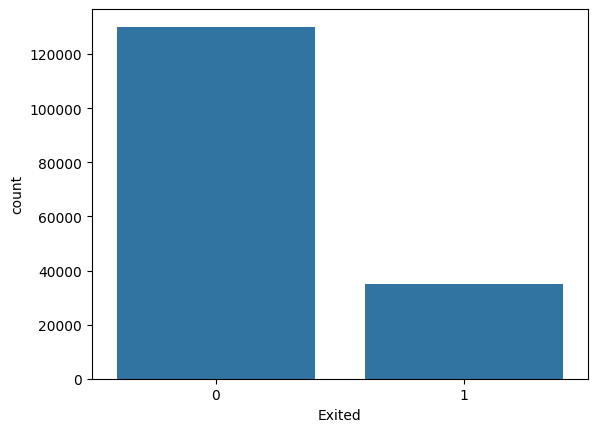

In [8]:
sns.countplot(data=df,x='Exited')

In [9]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


## Data Cleaning

In [10]:
df.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### Removing unnecessary columns

In [11]:
df = df.drop(['id','CustomerId','Surname'],axis=1)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


#### Group the age in bins of 10 years

In [13]:
df['Age'].max()

92.0

In [14]:
df['Age'].min()

18.0

In [15]:
labels = ["{0} - {1}".format(i, i + 9) for i in range(18, 92, 10)]

df['age_group'] = pd.cut(df.Age, range(1, 98, 12), right=False, labels=labels)

In [16]:
df['age_group'].unique()

['38 - 47', '48 - 57', '68 - 77', '58 - 67', '28 - 37', '78 - 87', '88 - 97']
Categories (8, object): ['18 - 27' < '28 - 37' < '38 - 47' < '48 - 57' < '58 - 67' < '68 - 77' < '78 - 87' < '88 - 97']

In [17]:
df.drop(['Age'],axis=1,inplace=True)

# Data Exploration

In [18]:
import matplotlib.pyplot as plt

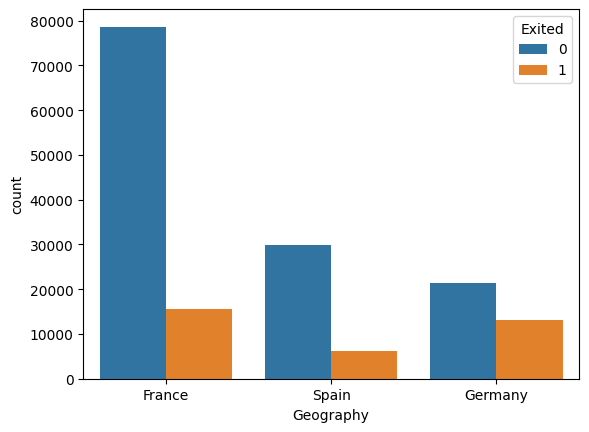

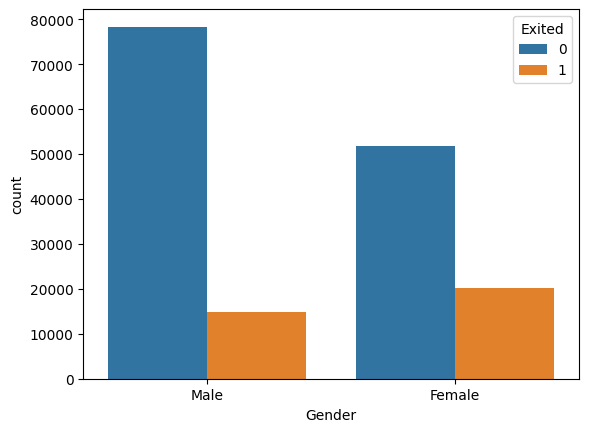

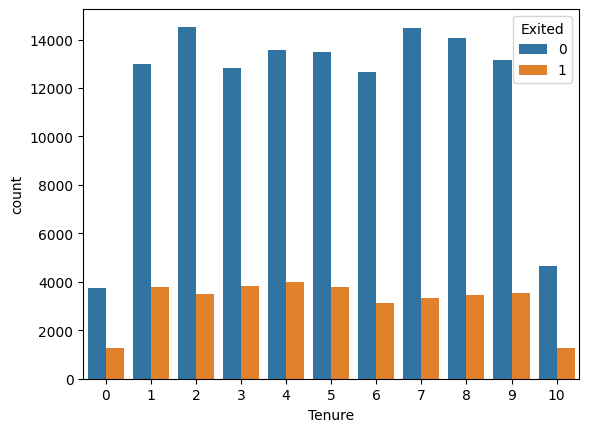

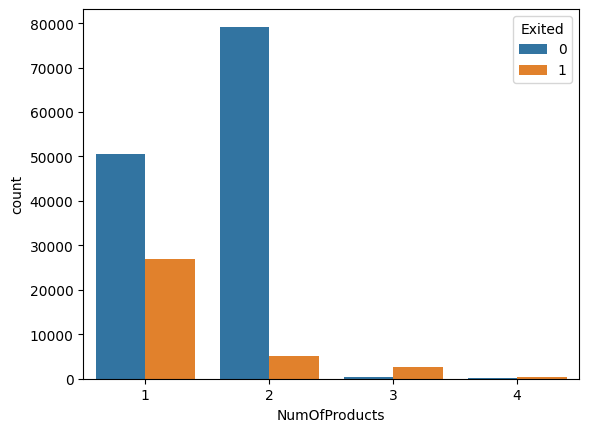

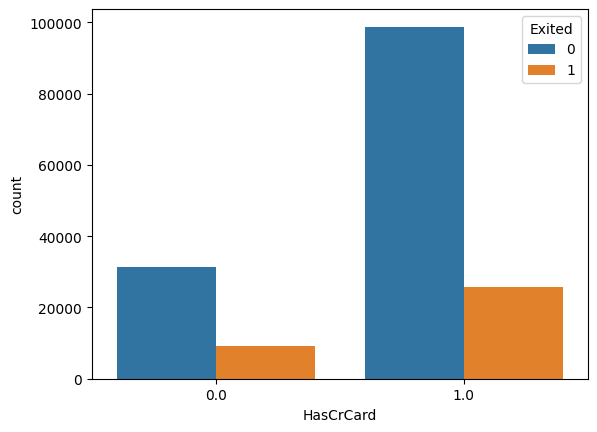

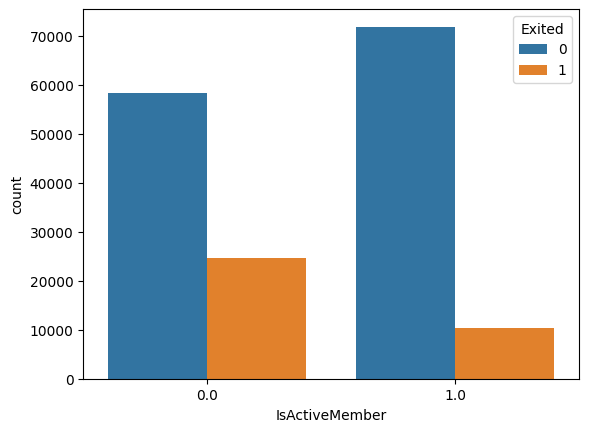

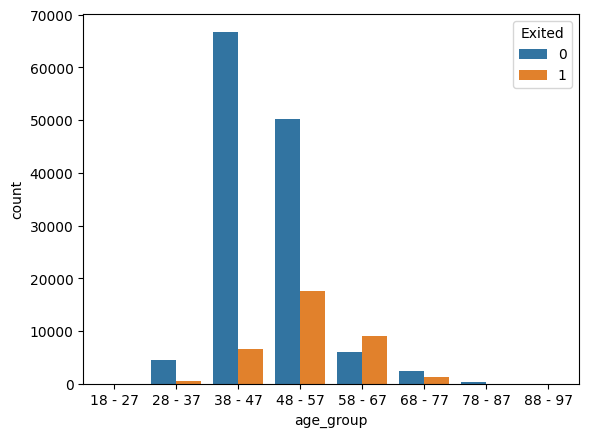

In [19]:
for i, predictor in enumerate(df.drop(columns=['Exited','CreditScore','Balance','EstimatedSalary'])):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Exited')

#### Convert all the categorical variables into dummy variables

In [20]:
df = pd.get_dummies(df,dtype=int)
df.head()

,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,...,Gender_Female,Gender_Male,age_group_18 - 27,age_group_28 - 37,age_group_38 - 47,age_group_48 - 57,age_group_58 - 67,age_group_68 - 77,age_group_78 - 87,age_group_88 - 97
0,668,3,0.00,2,1.0,0.0,181449.97,0,1,0,...,0,1,0,0,1,0,0,0,0,0
1,627,1,0.00,2,1.0,1.0,49503.50,0,1,0,...,0,1,0,0,1,0,0,0,0,0
2,678,10,0.00,2,1.0,0.0,184866.69,0,1,0,...,0,1,0,0,0,1,0,0,0,0
3,581,2,148882.54,1,1.0,1.0,84560.88,0,1,0,...,0,1,0,0,1,0,0,0,0,0
4,716,5,0.00,2,1.0,1.0,15068.83,0,0,0,...,0,1,0,0,1,0,0,0,0,0


### Build a corelation of all predictors with 'Exited'

<Axes: >

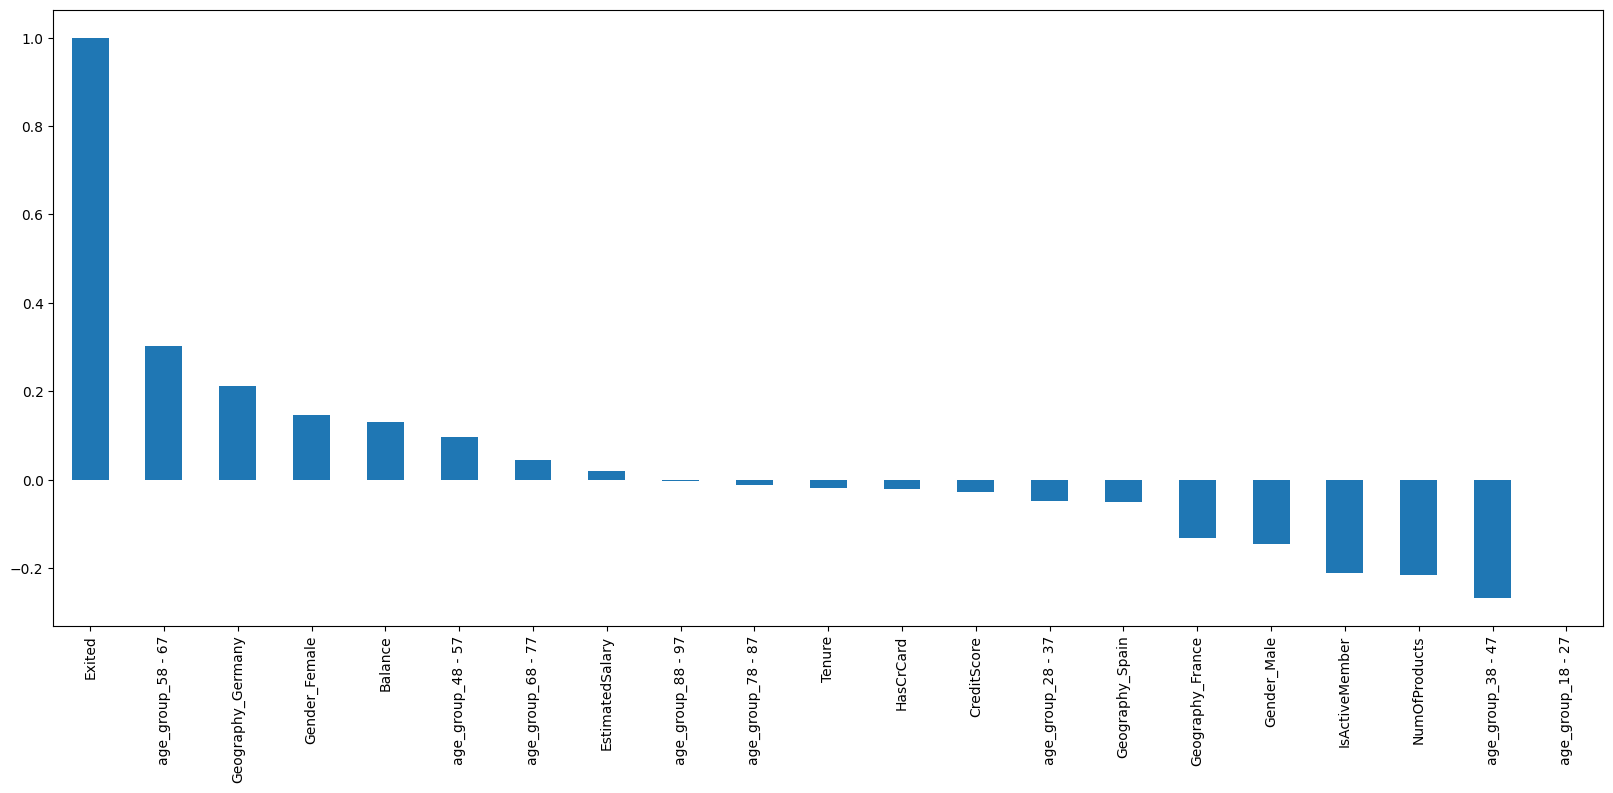

In [21]:
plt.figure(figsize=(20,8))
df.corr()['Exited'].sort_values(ascending = False).plot(kind='bar')

### Separating dependent and independent variables

In [22]:
X = df.drop('Exited',axis=1)
y = df['Exited']

### Handling imbalanced data

In [23]:
df['Exited'].value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

In [24]:
from imblearn.combine import SMOTEENN

In [25]:
X_res, y_res = SMOTEENN().fit_resample(X,y)

In [26]:
y_res.value_counts()

Exited
1    63331
0    53046
Name: count, dtype: int64

# Train-Test-Split

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X_res,y_res,test_size=0.20)

# Model Training

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn import metrics
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## 1. Decision Tree

In [32]:
DT = DecisionTreeClassifier()

In [33]:
DT.fit(X_train,y_train)
predict = DT.predict(X_test)
model_score = DT.score(X_test, y_test)
print(f"Model Score: {model_score}")
print(metrics.classification_report(y_test, predict))

Model Score: 0.8962880219969067
              precision    recall  f1-score   support

           0       0.89      0.88      0.89     10544
           1       0.90      0.91      0.91     12732

    accuracy                           0.90     23276
   macro avg       0.90      0.90      0.90     23276
weighted avg       0.90      0.90      0.90     23276



## 2. Random Forest

In [34]:
RF = RandomForestClassifier()

In [35]:
RF.fit(X_train,y_train)
pred2 = RF.predict(X_test)
model_score = RF.score(X_test, y_test)
print(f"Model Score: {model_score}")
print(metrics.classification_report(y_test, pred2))

Model Score: 0.9216789826430658
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     10544
           1       0.94      0.91      0.93     12732

    accuracy                           0.92     23276
   macro avg       0.92      0.92      0.92     23276
weighted avg       0.92      0.92      0.92     23276



## 3. Gradient Boosting Classifier

In [36]:
GBC = GradientBoostingClassifier()

In [37]:
GBC.fit(X_train,y_train)
pred3 = GBC.predict(X_test)
model_score = GBC.score(X_test, y_test)
print(f"Model Score: {model_score}")
print(metrics.classification_report(y_test, pred3))

Model Score: 0.9202182505585152
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     10544
           1       0.94      0.91      0.93     12732

    accuracy                           0.92     23276
   macro avg       0.92      0.92      0.92     23276
weighted avg       0.92      0.92      0.92     23276



## 4. Logistic Regression

In [59]:
LR = LogisticRegression(max_iter=10000)

In [60]:
LR.fit(X_train,y_train)
pred4 = LR.predict(X_test)
model_score = LR.score(X_test, y_test)
print(f"Model Score: {model_score}")
print(metrics.classification_report(y_test, pred4))

Model Score: 0.8971043134559202
              precision    recall  f1-score   support

           0       0.86      0.92      0.89     10544
           1       0.93      0.87      0.90     12732

    accuracy                           0.90     23276
   macro avg       0.90      0.90      0.90     23276
weighted avg       0.90      0.90      0.90     23276



C:\Users\Kunal\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of f AND g EVALUATIONS EXCEEDS LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Logistic Regression

In [40]:
KN1 = KNeighborsClassifier()

In [41]:
KN1.fit(X_train,y_train)
pred5 = KN1.predict(X_test)
model_score = KN1.score(X_test, y_test)
print(f"Model Score: {model_score}")
print(metrics.classification_report(y_test, pred5))

Model Score: 0.8980494930400412
              precision    recall  f1-score   support

           0       0.91      0.86      0.88     10544
           1       0.89      0.93      0.91     12732

    accuracy                           0.90     23276
   macro avg       0.90      0.89      0.90     23276
weighted avg       0.90      0.90      0.90     23276



# Saving best the model (RandomForest - 92%) 

In [88]:
RF.fit(X_res, y_res)

RandomForestClassifier()

In [89]:
import joblib

In [90]:
joblib.dump(RF, 'model')

['model']